In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model import Kernel
from model import utils as mutils
import importlib
import torch


In [2]:
configs=importlib.import_module('configs.Unet.unet_ds')
config=configs.get_config()

In [3]:
model=mutils.create_model(config)

In [4]:
ckt=torch.load('/home/arpanp/FusionNet/Kernel_Learning/workdir/checkpoints-meta/checkpoint.pth')
model.load_state_dict(ckt['model'])

<All keys matched successfully>

In [19]:
hr_image=np.load('/home/arpanp/Downloads/Data/Registration_slices/test/HR/AD_F11_90_AD_F11_90_slice_61.npy').astype(np.float32)
lr_image=np.load('/home/arpanp/Downloads/Data/Registration_slices/test/LR/AD_F11_90_AD_F11_90_slice_61.npy').astype(np.float32)

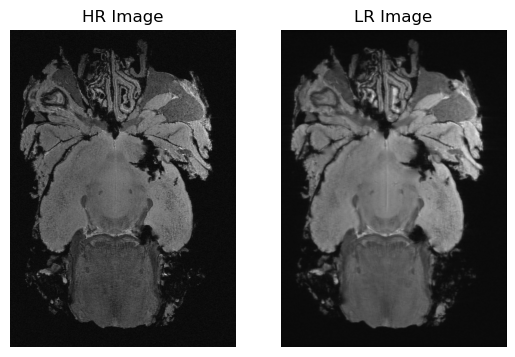

In [20]:
plt.subplot(1,2,1)
plt.imshow(hr_image,cmap='gray')
plt.title('HR Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(lr_image,cmap='gray')
plt.title('LR Image')
plt.axis('off')
plt.show()

In [7]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [8]:
psnr=peak_signal_noise_ratio(hr_image,lr_image,data_range=1.0)
ssim=structural_similarity(hr_image,lr_image,data_range=1.0)
print('PSNR:',psnr)
print('SSIM:',ssim)

PSNR: 31.82755422049269
SSIM: 0.8038410728655314


In [9]:
hr_tensor=torch.from_numpy(hr_image).unsqueeze(0).unsqueeze(0).to(torch.device('cuda'))
lr_pred=model(hr_tensor)

In [10]:
lr_pred=lr_pred.squeeze(0).squeeze(0).detach().cpu().numpy()

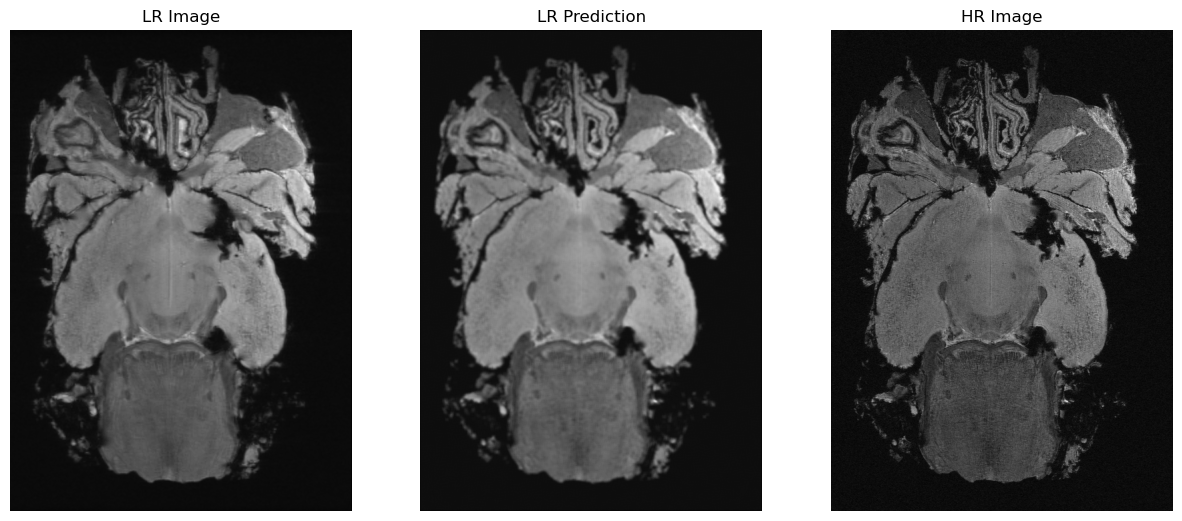

In [11]:
plt.figure(figsize=(15,15))
plt.subplot(1,3,1)
plt.imshow(lr_image,cmap='gray')
plt.title('LR Image')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(lr_pred,cmap='gray')
plt.title('LR Prediction')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(hr_image,cmap='gray')
plt.title('HR Image')
plt.axis('off')
plt.show()

In [12]:
psnr=peak_signal_noise_ratio(lr_pred,lr_image,data_range=1.0)
ssim=structural_similarity(lr_pred,lr_image,data_range=1.0)
print('PSNR:',psnr)
print('SSIM:',ssim)

PSNR: 34.907388172388316
SSIM: 0.9284663809961419
